# Table of Contents:
1. How to filter a large CSV for specific data, How to sort a CSV by date
2. How to display data from CSV on a map using ```.scatter_mapbox()``` from ```plotly_express``` library
3. How to make graphs using ```matplotlib```

### IMPORTANT NOTE: I designed this notebook to be modular, so you do NOT need to run the entire file. You can skip ahead to the relevant section. This is why there are duplicate instances of df=pd.read_csv() for the example CSV.

## Tutorial: How to filter a large CSV for specific data

In this example, I will show how to make a new CSV file based on rows that were filtered out of a larger CSV. The data I want to save in the new CSV are the rows that match the image names in a folder. In this case, the original data is the CSV file containing all the scores for last year's data. I want to make a new CSV that only contains the information associated with images in the ```2025_Survey_Images``` folder.

First, you need to import the os and pandas library. The ```os``` library is used to list all the images in the ```2025_Survey_Images```. The ```pandas``` library is used to store and filter the data in dataframes, and import/export as CSV.

In [1]:
import os
import pandas as pd

Here I stored the path to the image directory, the original CSV name, and my new CSV name as variables. If you want to reuse this code for a different image directory, you will need to change the path for ```image_directory```. If you are not sure what your current working directory is, you can run the command ```pwd``` in the terminal. This will print the path to your current working directory.

In [10]:
#path to the directory containing the images
image_directory = os.path.join("..", "Images", "2025_Survey_Images")

#for these examples I will be using the old OpenAI scores
original_csv_name = os.path.join("..", "Scores", "2024_OpenAI_Scores.csv")

#i have also customized the output CSV to export to the Scores folder
new_csv_name = os.path.join("..", "Scores", "2025_Survey_Images_Old_Scores.csv")

Let's start by storing all the files in the ```image_directory``` in a new variable: ```all_files```.

You can count the number of files in a directory by passing in the result of ```os.listdir()``` in ```len()```.

In [11]:
all_files = os.listdir(image_directory)

print(f"Number of files in this directory: {len(all_files)}")

Number of files in this directory: 100


This is an example of a "list comprehension" in Python. You can run for loops and store the output as a list with just one line of code! (pretty cool huh)  

What this line of code is doing is looping through all the each file in ```all_files```, and adding the file name to ```image_filenames``` if the current file ends with .jpg. ```file[:-4]``` removes the .jpg from the original file name. This step is necessary because the entries in the ```ImageID``` column for the original CSV is formatted without the .jpg.

In [12]:
image_filenames = [file[:-4] for file in all_files if file.endswith(".jpg")]

Now this is the part where you load the original CSV, remove any unnecessary Unnamed columns, and filter the dataframe to only include rows where ImageID is in the list of image filenames.

In [13]:
original_df = pd.read_csv(original_csv_name)

#this line doesn't do anything since the current csv has no unnamed columns
#but you can modify 'Unnamed' to be other columns you are trying to exclude
original_df = original_df.loc[:, ~original_df.columns.str.contains("^Unnamed")] 

filtered_df = original_df[original_df["ImageID"].isin(image_filenames)]

#print the filtered df to verify the output
print("\nFiltered DataFrame:")
print(filtered_df)

#save the filtered df to a new .csv file
filtered_df.to_csv(new_csv_name, index=False) #always make sure to keep index=False to prevent a new Index column from being added


Filtered DataFrame:
         ImageID   Latitude   Longitude  Elevation               Neighborhood  \
0        image_0  47.608058 -122.318160         94                 First Hill   
3        image_3  47.616376 -122.323433         87                   Broadway   
4        image_4  47.609318 -122.319385        107                 First Hill   
6        image_6  47.604570 -122.331706         40  Central Business District   
7        image_7  47.618231 -122.338688         28             Denny Triangle   
...          ...        ...         ...        ...                        ...   
3425  image_3736  47.598436 -122.324947         28     International District   
4380  image_4818  47.619570 -122.340807         30           South Lake Union   
5234  image_5800  47.609479 -122.331031         78                 First Hill   
6213  image_6915  47.601728 -122.320311         77             Yesler Terrace   
7259  image_8149  47.597442 -122.328225         21     International District   

      

#### Bonus tutorial: How to sort a CSV by date

In this example, I will show how to make a new CSV file that has rows sorted from newest to oldest date.  
All you have to do is convert the ```Date``` column to datetime format using ```pd.to_datetime``` and then create a new dataframe that uses ```.sort_values(by='Date')``` 

In [14]:
new_csv_name = os.path.join("..", "Scores", "2025_Survey_Images_Old_Scores.csv") #same as new_csv_name from first example
df = pd.read_csv(new_csv_name)

df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df_sorted = df.sort_values(by="Date", ascending=False)
df_sorted.to_csv(os.path.join("..", "Scores", "2025_Survey_Images_Old_Scores_by_Date.csv"), index=False)

## Tutorial: How to display data from a CSV on a map

In [15]:
import pandas as pd
import plotly_express as px #the library that shows maps

new_csv_name = os.path.join("..", "Scores", "2025_Survey_Images_Old_Scores.csv") #same as new_csv_name from first example
df = pd.read_csv(new_csv_name)

#### .scatter_mapbox() parameters:
* ```lat=``` *insert name of column in df that has latitude coordinates*
* ```lon=``` *insert name of column in df that has longitude coordinates*
* ```color=``` to set the color of the points
* ```labels=``` a list of what columns to show when hovering over a point
* ```category_orders=``` define the categories in the data
* ```hover_name=``` to set which column's data you want to show when you hover on a point
* ```color_continuous_scale=``` customize which colors to use
an alternative to ```color_continuous_scale``` is ```color_discrete_map```

Things that help with sizing and centering of the map on the points. You kinda have to experiment with the number to get what you want. But the numbers I use are: 
* ```zoom=``` 13
* ```center=``` needs to be passed in as a dictionary with {"lat": 47.6099, "lon": -122.3438}
* ```mapbox_style=``` I prefer the default of "open-street-map"
* ```width=``` 880
* ```height=``` 700
* ```title=``` map title

In [16]:
#colors
color_list = ["red", "orange", "yellow", "yellowgreen", "green"]

#category_orders
walkability = ["Not at all walkable", "Slightly walkable", "Moderately walkable", "Very walkable", "Extremely walkable"]
numbers = [int(i) for i in range(1, 11)]
categories = {
    "Walkability Rating": walkability,
    "Score": numbers
}

column_list = ["OpenAI Score", "Walkability Rating", "Tags", "Neighborhood"]

#zoom level
zoom_level = 13

#center of the map
center_lat = 47.6099
center_long = -122.3438
center_point = {
    "lat": center_lat,
    "lon": center_long
}

#size of the figure
w = 880
h = 700

map_style = "open-street-map"

## Mapping example 1: Showing location of survey images

You can customize ```col_name``` and ```hov_name``` to be the names of the columns within the dataframe that you want to show. 

In [17]:
map_title = "OpenAI Scores in Seattle Downtown Area"
col_name = "OpenAI Score"
hov_name = "Neighborhood"
fig = px.scatter_mapbox(df, lat="Latitude", lon="Longitude", color=col_name, category_orders=categories,
                        hover_name=hov_name, color_continuous_scale=color_list, labels=column_list,
                        zoom=zoom_level, center=center_point, mapbox_style=map_style,
                        width=w, height=h, title=map_title)
fig.show()


## Mapping example 2: Using full dataset

In [18]:
df2 = pd.read_csv(os.path.join("..", "Scores", "2024_OpenAI_Scores.csv"))
map_title = "OpenAI Scores in Seattle Downtown Area"
col_name = "OpenAI Score"
hov_name = "Neighborhood"
fig = px.scatter_mapbox(df2, lat="Latitude", lon="Longitude", color=col_name, category_orders=categories,
                        hover_name=hov_name, color_continuous_scale=color_list, labels=column_list,
                        zoom=zoom_level, center=center_point, mapbox_style=map_style,
                        width=w, height=h, title=map_title)
fig.show()

## Tutorial: How to make graphs

For these examples I will be using the ```matplotlib``` library, but you can also look into using ```seaborn``` if that's your preference. The commands are similar anyways.

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

csv = os.path.join("..", "Scores", "2025_Survey_Images_Old_Scores.csv") #same as new_csv_name from first example
dataframe = pd.read_csv(csv)

### Creating a histogram showing the distribution of scores

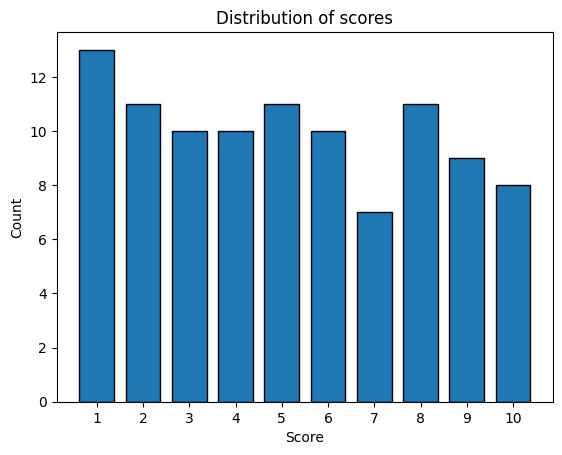

In [23]:
def createHistogram(dataframe, bins=range(1,12), x="", y="", title=""):
    plt.hist(dataframe, bins=bins, rwidth=0.75, align="left", edgecolor='black')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.xticks(range(1, 11))
    plt.title(title)
    plt.show()

createHistogram(dataframe["OpenAI Score"], x="Score", y="Count", title="Distribution of scores")

### Creating a bar chart showing distribution of scores as categorical variables

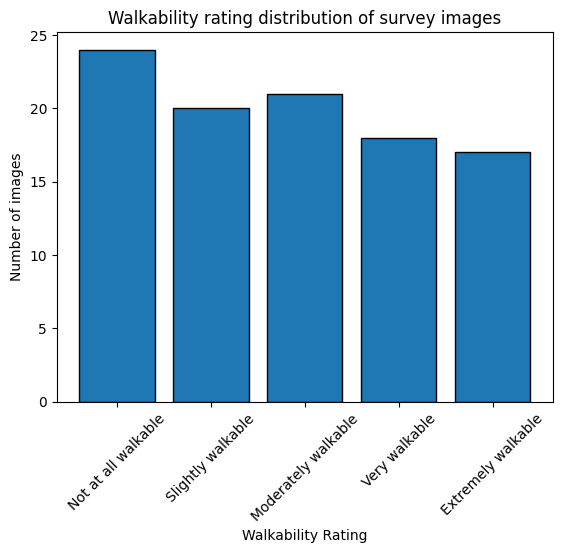

In [21]:
order = ["Not at all walkable", "Slightly walkable", "Moderately walkable", "Very walkable", "Extremely walkable"]

dataframe["Walkability Rating"] = pd.Categorical(dataframe["Walkability Rating"], categories=order, ordered=True)
walkability_counts = dataframe["Walkability Rating"].value_counts().reindex(order)

plt.bar(walkability_counts.index, walkability_counts.values, edgecolor="black")
plt.xlabel("Walkability Rating")
plt.xticks(rotation=45)
plt.ylabel("Number of images")
plt.title("Walkability rating distribution of survey images")
plt.show()

### Creating a bar chart showing the number of images per neighborhood

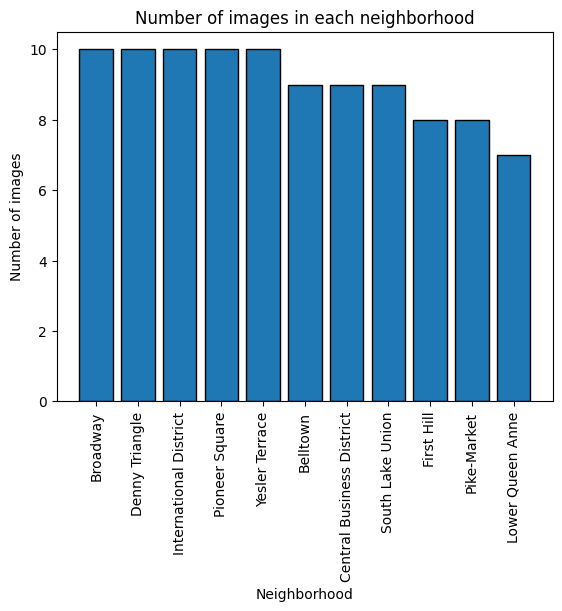

In [22]:
dataframe["Neighborhood"] = pd.Categorical(dataframe["Neighborhood"], ordered=True)
neighborhood_counts = dataframe["Neighborhood"].value_counts()

plt.bar(neighborhood_counts.index, neighborhood_counts.values, edgecolor="black")
plt.xlabel("Neighborhood")
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.title("Number of images in each neighborhood")
plt.show()

### Creating a grid of histograms based on grouping scores by neighborhood

The distribution looks a little weird for this one because it is just for the 100 survey images.

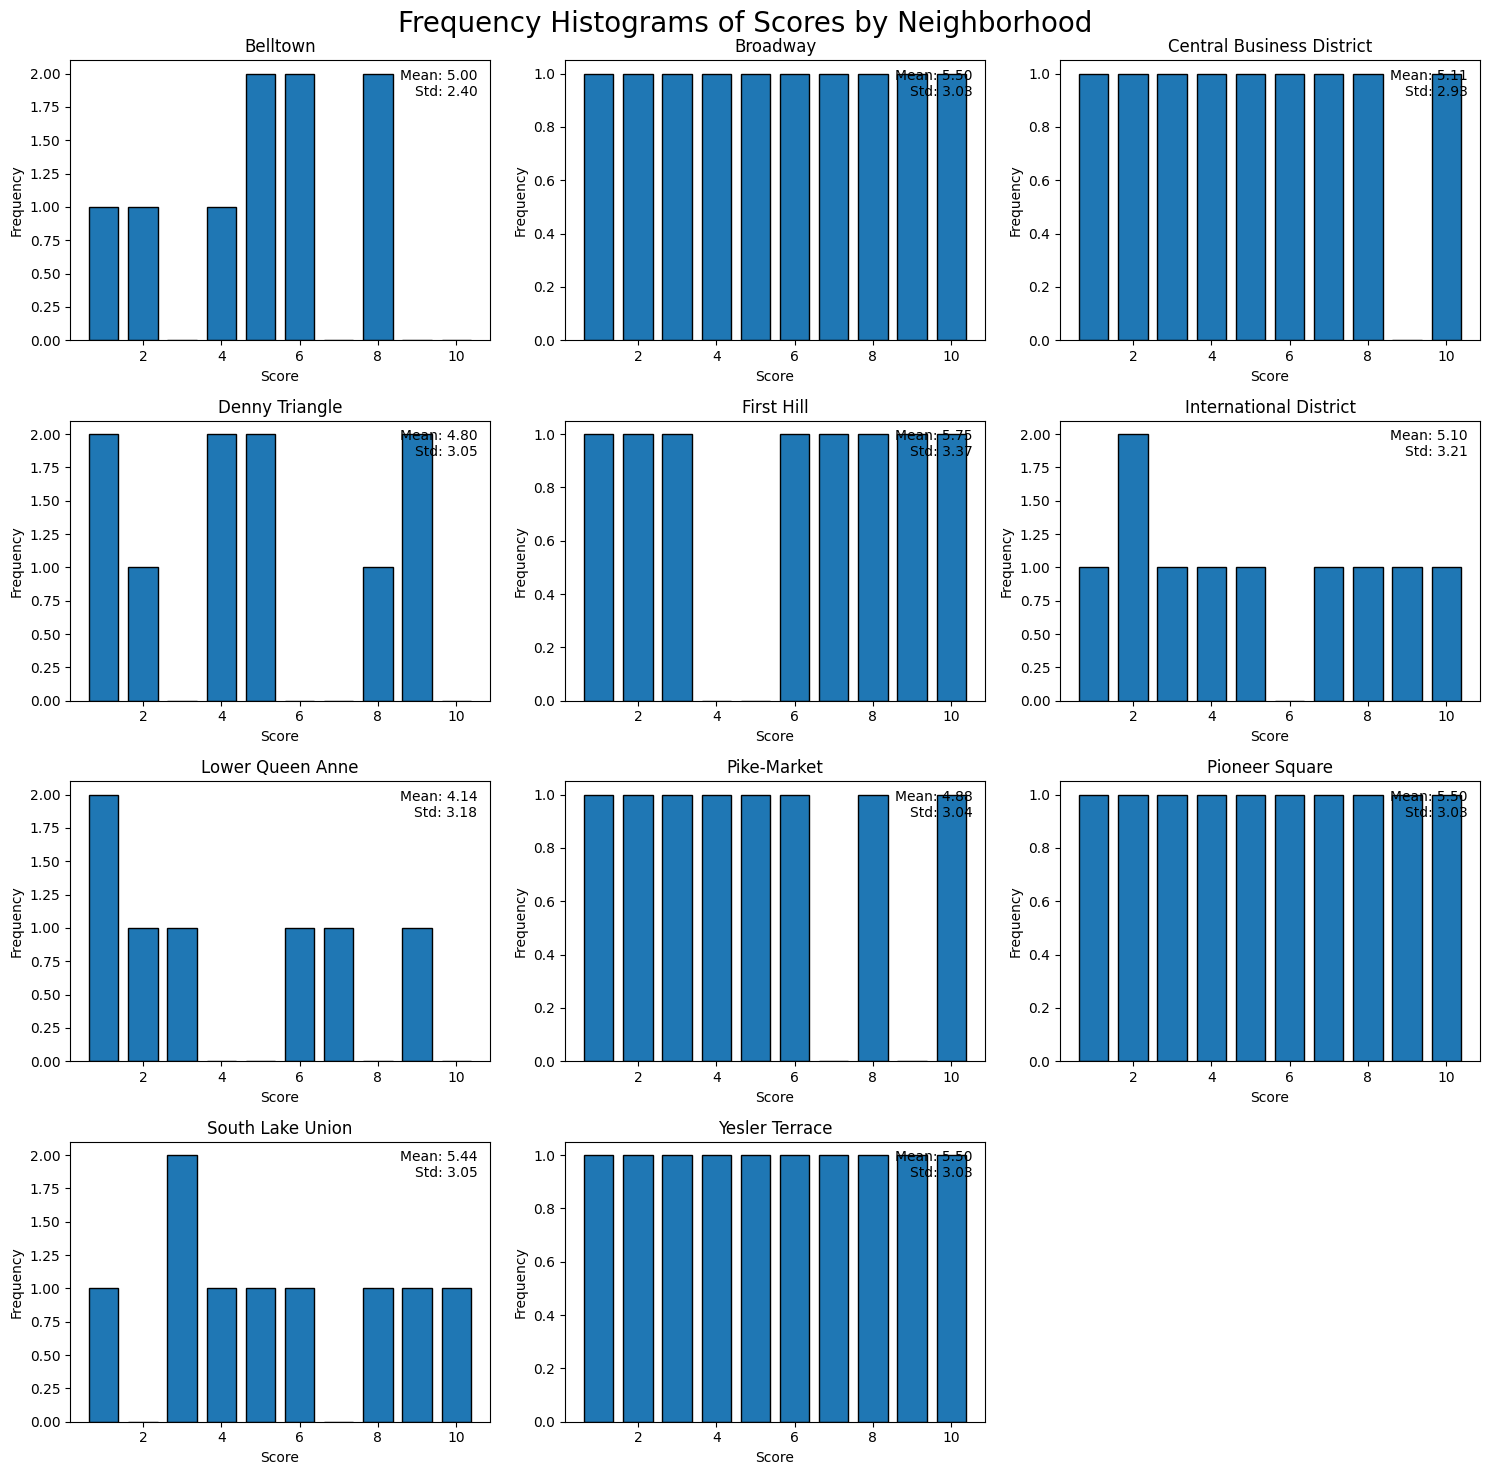

In [24]:
grouped = dataframe.groupby("Neighborhood")

fig1, axes1 = plt.subplots(nrows=4, ncols=3, figsize=(15, 15))
fig1.suptitle("Frequency Histograms of Scores by Neighborhood", fontsize=20)

axes1 = axes1.flatten()

for (neighborhood, data), ax1 in zip(grouped, axes1):
    scores = data["OpenAI Score"]
    mean = scores.mean()
    std_dev = scores.std()

    ax1.hist(data["OpenAI Score"], bins=range(1,12), rwidth=0.75, align="left", edgecolor="black")
    ax1.set_title(f'{neighborhood}')
    ax1.set_xlabel("Score")
    ax1.set_ylabel("Frequency")

    #display mean and standard deviation under the plot
    ax1.text(0.97, 0.97, f"Mean: {mean:.2f}\nStd: {std_dev:.2f}", 
            transform=ax1.transAxes, verticalalignment="top", 
            horizontalalignment="right", fontsize=10)

axes1[-1].axis("off")

plt.tight_layout()
plt.show()

### Creating a grid of histograms for the full dataset by neighborhood

I made it so that you can just copy and paste this entire last code block and it will work wherever because this will probably be the most useful.

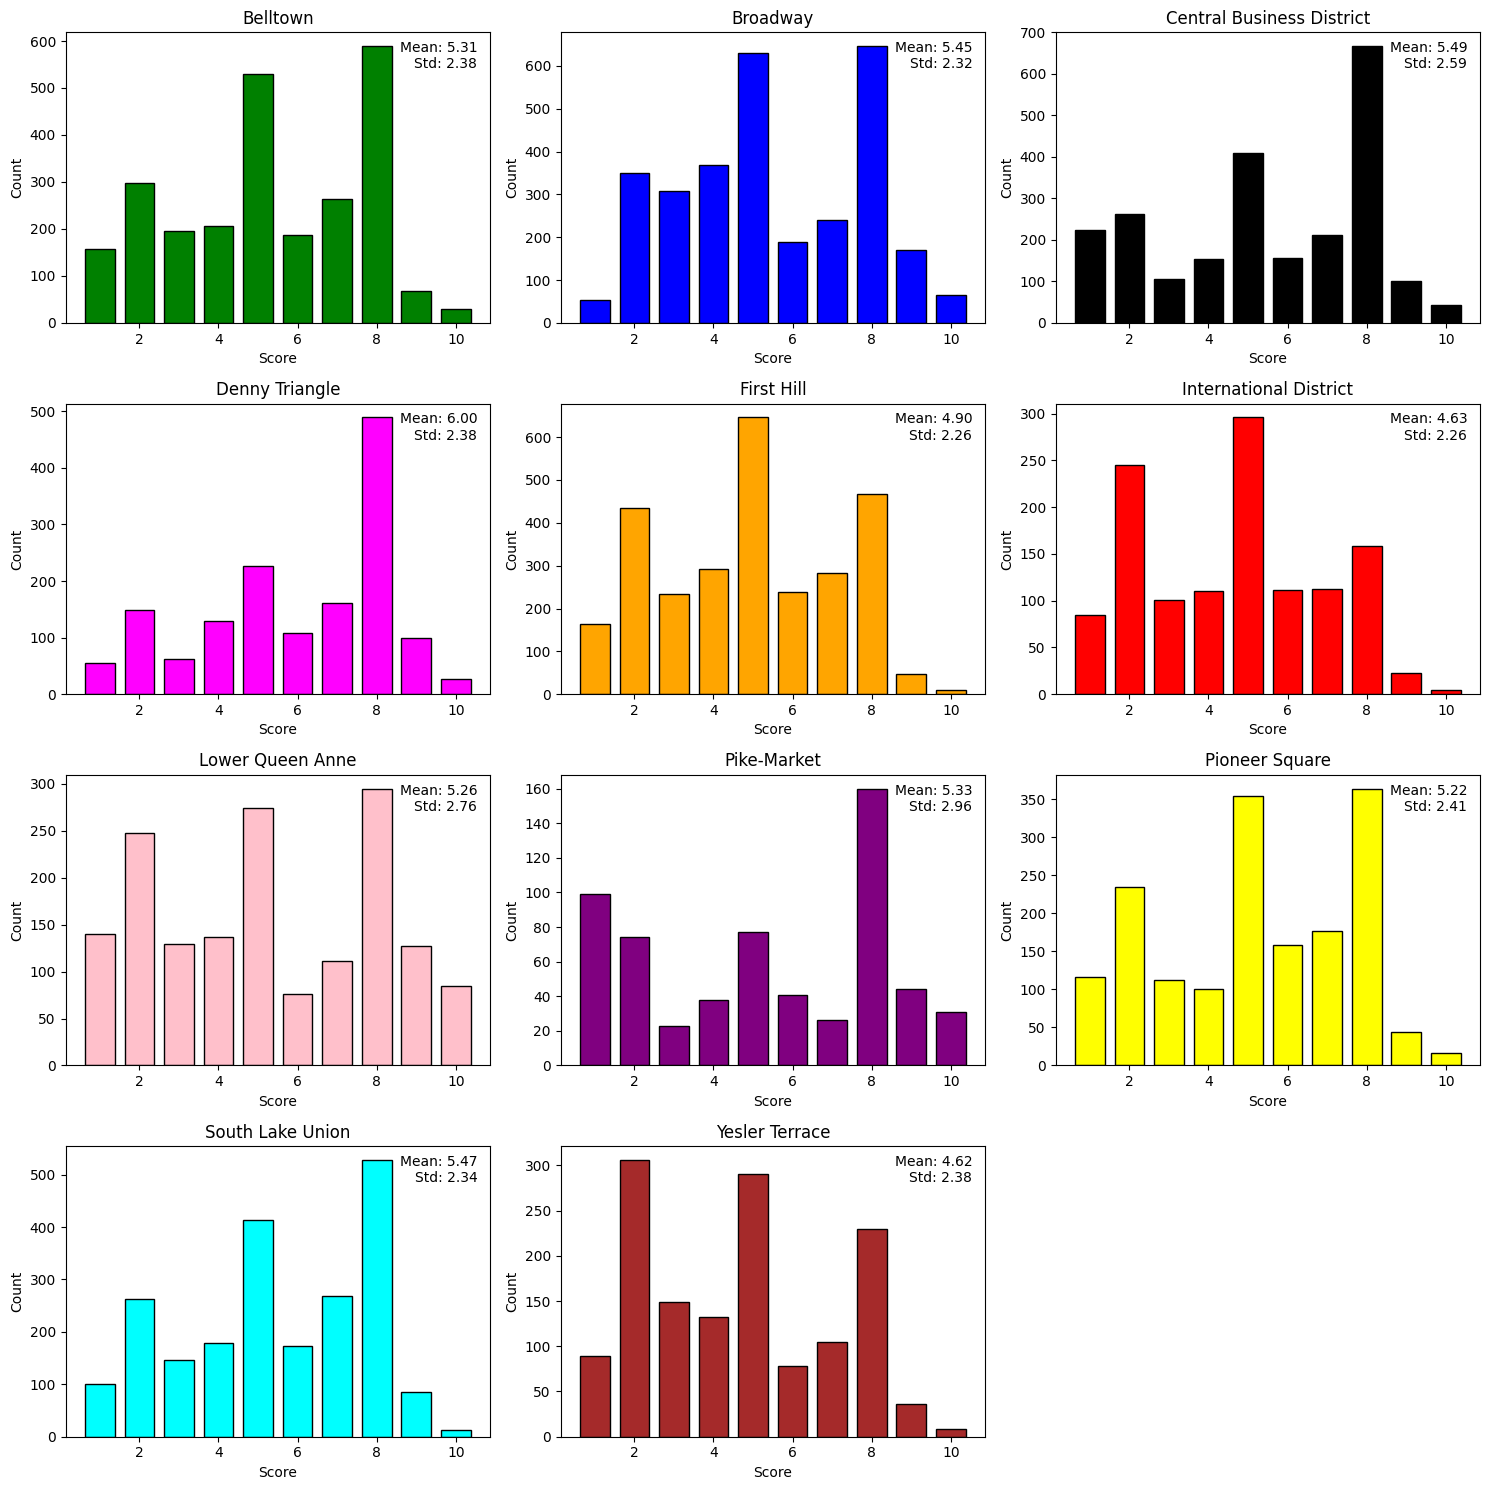

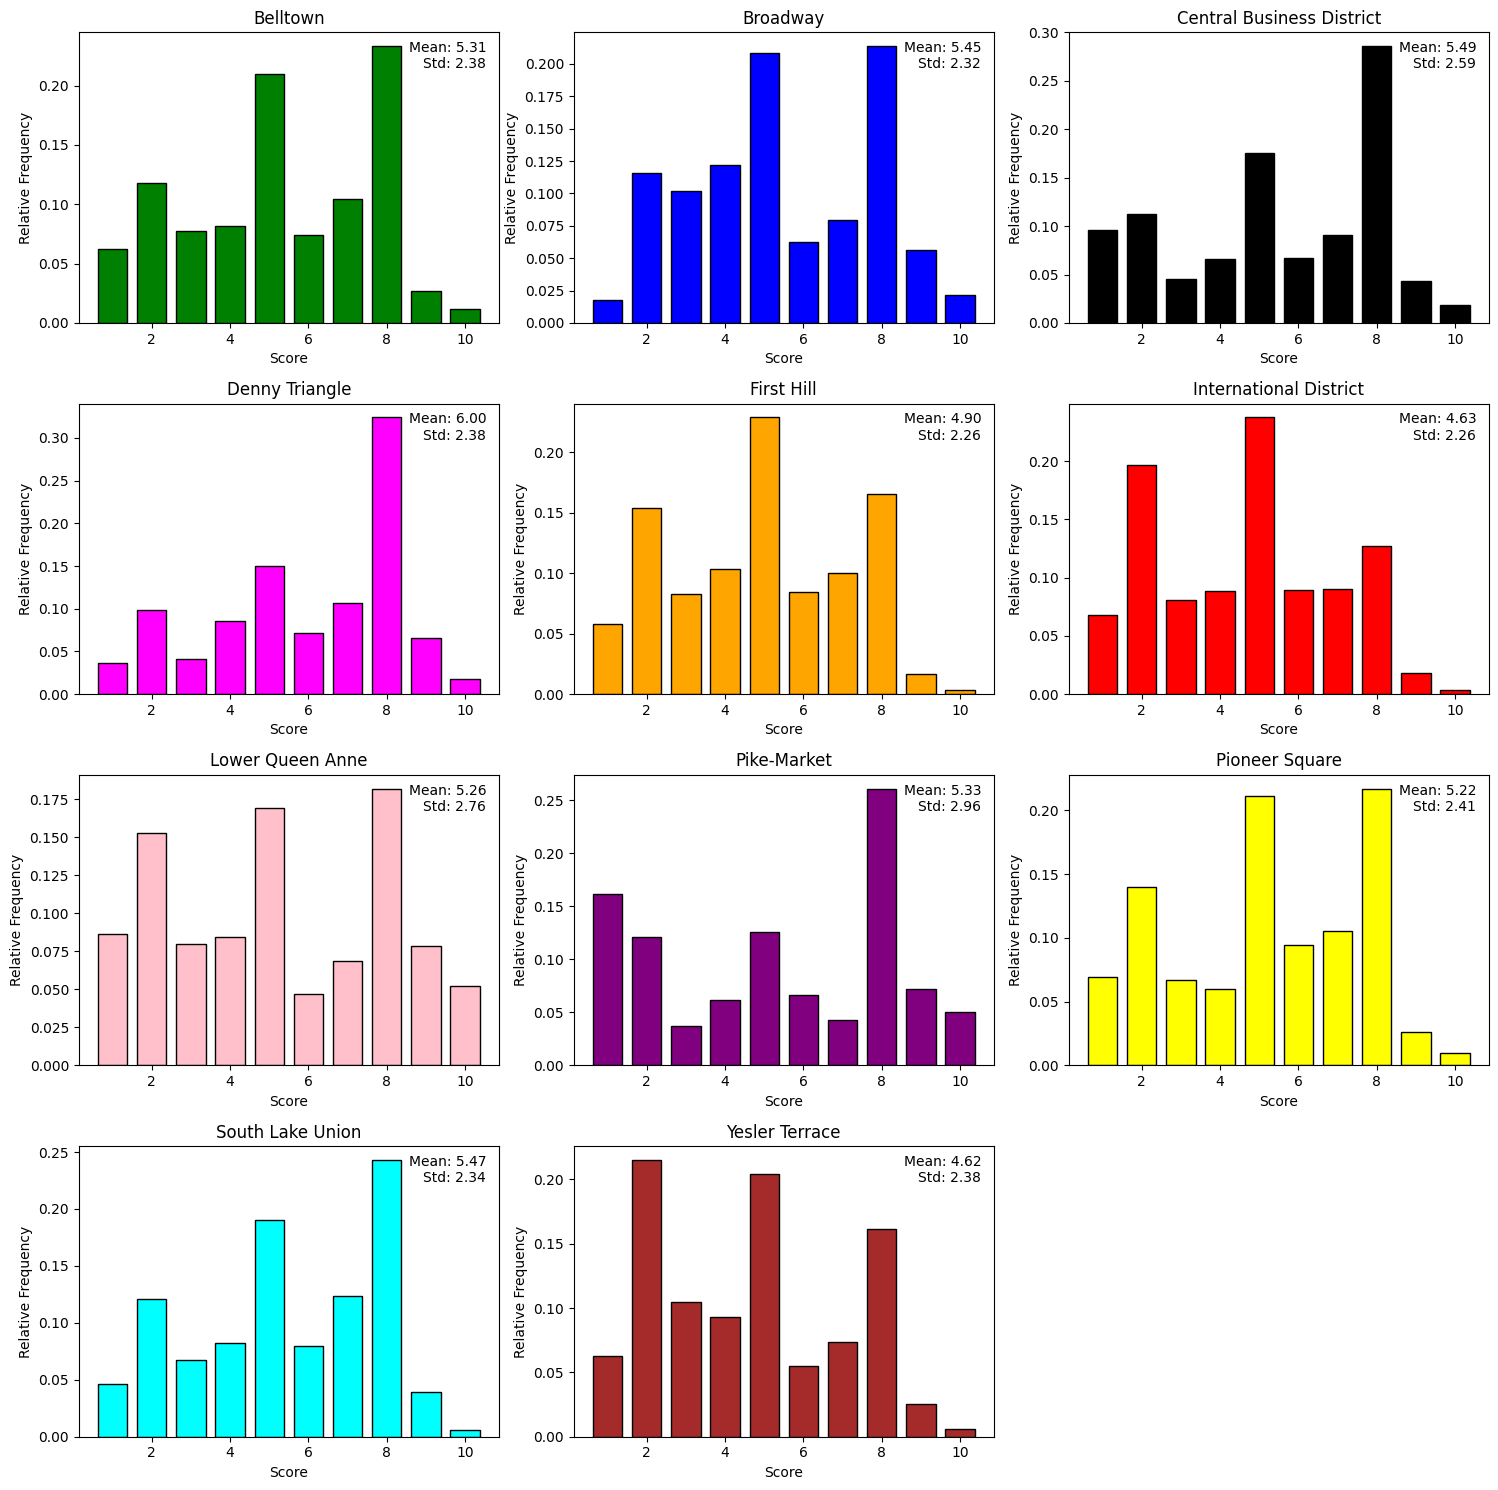

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

csv = os.path.join("..", "Scores", "2024_OpenAI_Scores.csv") #change this to be whatever your csv file name is
df_for_grid = pd.read_csv(csv)

colors = ["green", "blue", "black", "magenta", "orange", "red", "pink", "purple", "yellow", "cyan", "brown"]
neighborhoods_to_exclude = ["Interbay", "SODO", "No matching district found"] #excluded because not a significant number of images in this neighborhood
df_for_grid = df_for_grid[~df_for_grid["Neighborhood"].isin(neighborhoods_to_exclude)]
grouped = df_for_grid.groupby("Neighborhood")

#frequency based
fig1, axes1 = plt.subplots(nrows=4, ncols=3, figsize=(15, 15))
#fig.suptitle('Frequency Histograms of Scores by Neighborhood', fontsize=20) uncomment this line to add a title
axes1 = axes1.flatten()

for (neighborhood, data), ax1, color in zip(grouped, axes1, colors):
    scores = data["OpenAI Score"]
    mean = scores.mean()
    std_dev = scores.std()

    #frequency based
    ax1.hist(scores, bins=range(1,12), rwidth=0.75, align="left", edgecolor="black", color=color)
    ax1.set_title(f'{neighborhood}')
    ax1.set_xlabel("Score")
    ax1.set_ylabel("Count")
    ax1.text(0.97, 0.97, f"Mean: {mean:.2f}\nStd: {std_dev:.2f}", 
            transform=ax1.transAxes, verticalalignment="top", 
            horizontalalignment="right", fontsize=10)

axes1[-1].axis("off")
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.tight_layout()
plt.show()

#density based
fig2, axes2 = plt.subplots(4, 3, figsize=(15, 15))
#fig2.suptitle("Density Histograms of Scores by Neighborhood", fontsize=20)
axes2 = axes2.flatten()

for (neighborhood, data), ax2, color in zip(grouped, axes2, colors):
    scores = data["OpenAI Score"]
    mean = scores.mean()
    std_dev = scores.std()
    
    #density based
    ax2.hist(scores, bins=range(1,12), rwidth=0.75, align="left", edgecolor="black", color=color, density=True)
    ax2.set_title(f'{neighborhood}')
    ax2.set_xlabel("Score")
    ax2.set_ylabel("Relative Frequency")
    ax2.text(0.97, 0.97, f"Mean: {mean:.2f}\nStd: {std_dev:.2f}",
             transform=ax2.transAxes, verticalalignment="top",
             horizontalalignment="right", fontsize=10)

axes2[-1].axis("off")
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.tight_layout()
plt.show()

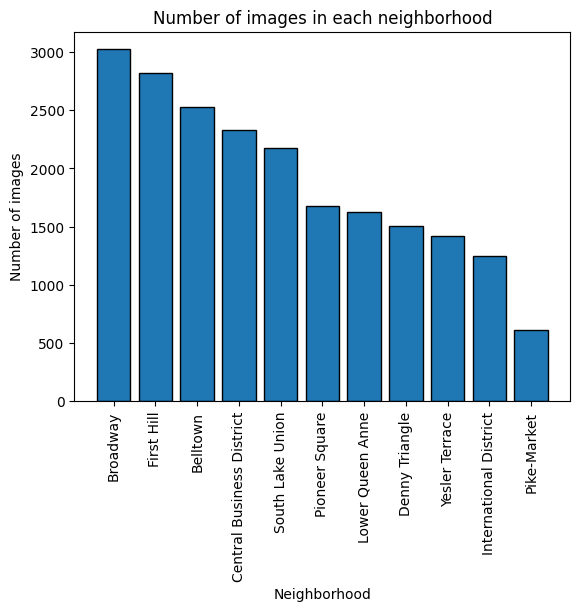

In [26]:
df_for_grid["Neighborhood"] = pd.Categorical(df_for_grid["Neighborhood"], ordered=True)
neighborhood_counts = df_for_grid["Neighborhood"].value_counts()

plt.bar(neighborhood_counts.index, neighborhood_counts.values, edgecolor="black")
plt.xlabel("Neighborhood")
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.title("Number of images in each neighborhood")
plt.show()